# Show Bias in frequency estimation from CWT

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sys import path
path.append('../wavelet/')
path.append('../signals/')

import wavelet_funcs as wf
from signals import cosine


In [215]:
from scipy.signal import periodogram

### Perfect cyclic cosine

In [163]:
int(1/dt)

20

In [201]:
dt = 0.05
t,s = cosine(10+dt, 2, int(1/dt))

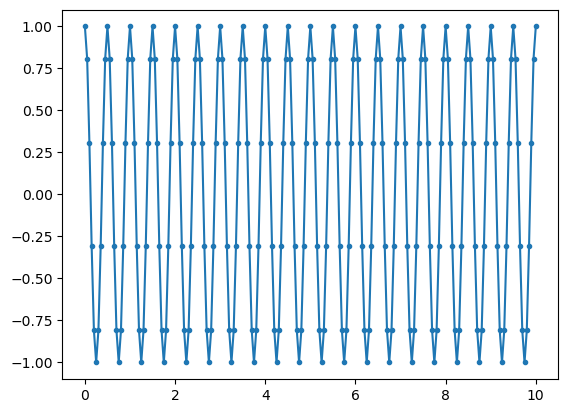

In [203]:
plt.plot(t, s, marker='.')

1.9482105673488956


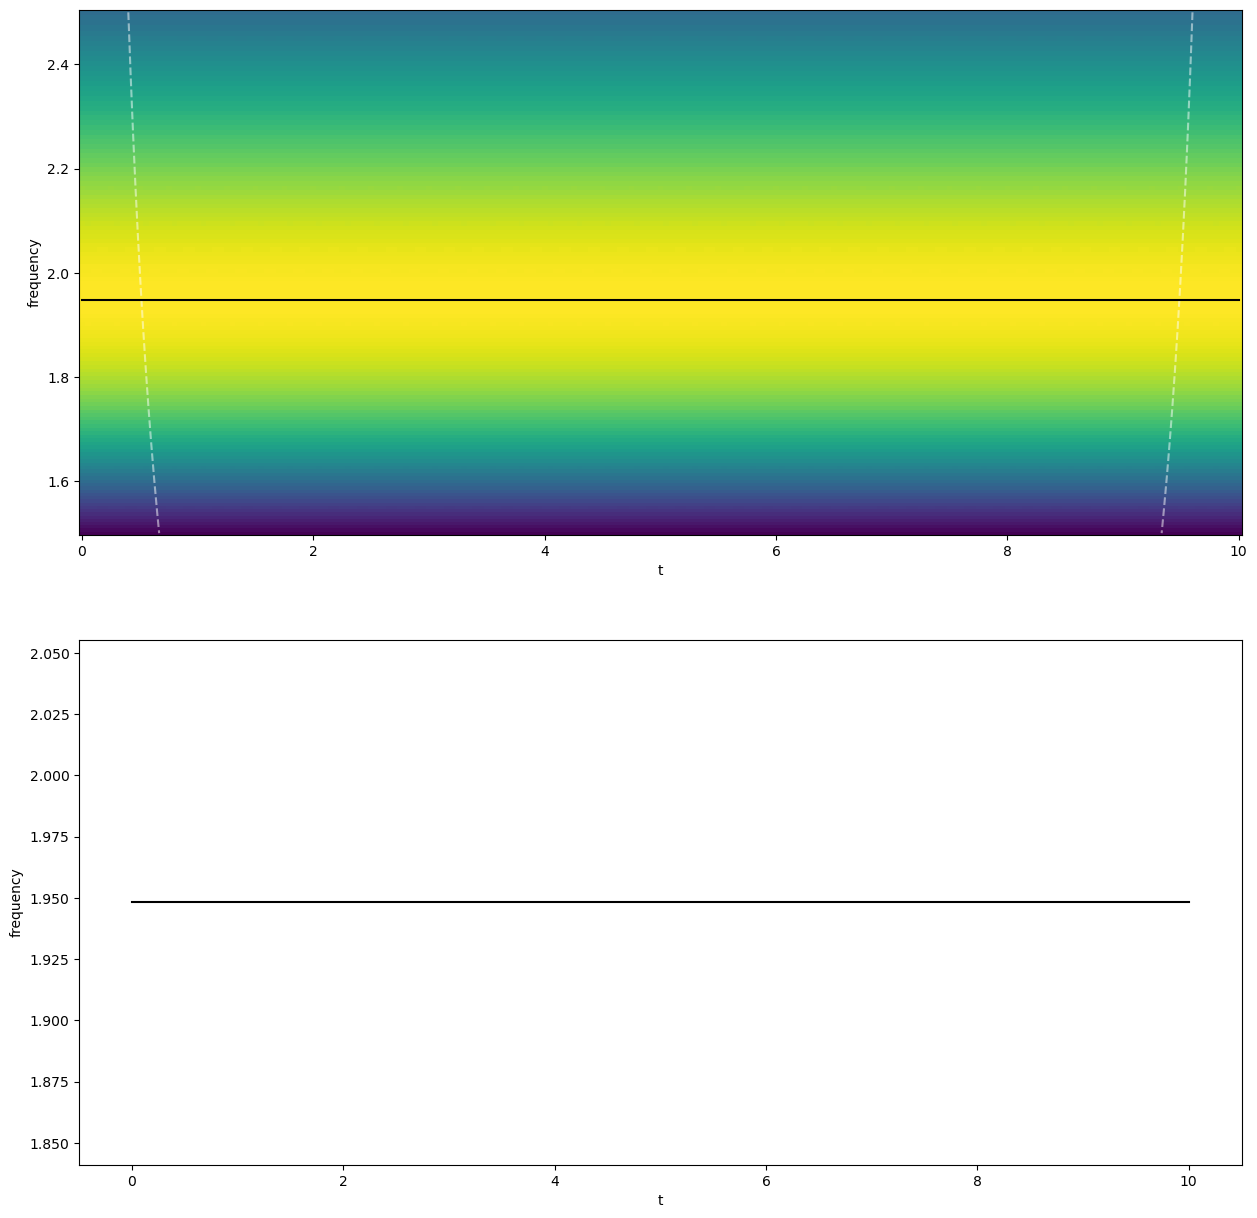

In [249]:
res = wf.cwt_with_coi(s,t,1.5,2.5,bandwidth=1,method='fft', padding_fraction=0.5, nscales=128, precision=18, pad_mode='reflect')
rdg = wf.wavelet_ridge(res.wt_coefs, res.f, res.t)
f, (ax,ax1) = plt.subplots(2,1,figsize=(15,15),)

wf.plot_cwt(abs(res.wt_coefs), res.f, res.t, coi=res.coi, ax=ax);
rdg.frequency.plot(ax=ax, color='k')
rdg.frequency.plot(ax=ax1, color='k')
print(rdg.frequency.mean().item())

2.0


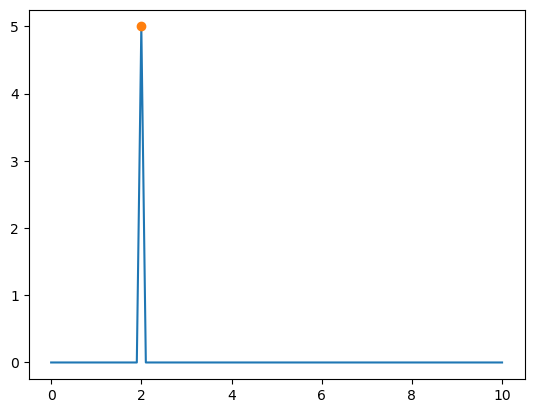

In [251]:
fs, p = periodogram(s[:-1], fs=1/dt)

fmax = fs[np.argmax(p)]
pmax = p[np.argmax(p)]

plt.plot(fs, p)
plt.plot(fmax, pmax, marker='o')
print(fmax)

## Frequency estimated from CWT is an underestimate

In [266]:
print(f'True frequency: {int(1/dt)}')
print(f'Fourier frequency estimate: {fmax}')
print(f'CWT frequency estimate: {rdg.frequency.mean().item():.3f}')

True frequency: 20
Fourier frequency estimate: 2.0
CWT frequency estimate: 1.948


## The Bias is growing for lower bandwidth
Reasons for the bias:
- Scale to frequency conversion using non-exact relationship between them (?)
- Leakage of negative frequencies into positive, so the peak along frequency dimension has a positive tail, and the maximum is shifted to lower frequencies (?)
- Other?